# Rising Bubble PINN: обучение по этапам

Ноутбук запускает тот же PyTorch pipeline, что и `train_rising_bubble.py`, но по отдельным этапам. После каждой ячейки этапа можно смотреть loss, checkpoints и графики истории.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
import torch

cwd = Path.cwd().resolve()
PROJECT_DIR = cwd if (cwd / "pinn").exists() else cwd / "diploma"
ROOT_DIR = PROJECT_DIR.parent
sys.path.insert(0, str(PROJECT_DIR))

from pinn.config import preset_config
from pinn.train import TrainingRun, resolve_device

print("project:", PROJECT_DIR)
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

project: D:\diploma_jupyter\diploma
torch: 2.10.0+cu128
cuda available: True


## 1. Конфигурация

`smoke` нужен для быстрой проверки. Для рабочего запуска поменяй `preset_name` на `default`; для максимально близкого к статье запуска - на `paper`.

In [4]:
preset_name = "paper"  # smoke | default | paper
cfg = preset_config(preset_name)

cfg.data_path = ROOT_DIR / "twophasePINN" / "cfd_data" / "rising_bubble.h5"
cfg.output_dir = PROJECT_DIR / "checkpoints"
cfg.device = "auto"  # auto | cpu | cuda | cuda:0
cfg.dtype = "float32"

# Примеры точечной настройки без CLI:
# cfg.epochs = (500, 500, 500)
# cfg.learning_rates = (1e-4, 5e-5, 1e-5)
# cfg.hidden_layers = (128, 128, 128, 128)
# cfg.batch_size = 4096  # ручной total batch size
# cfg.batch_size = None; cfg.num_batches = 20  # как у авторов: ceil(total_points / 20)

assert cfg.data_path.exists(), f"Не найден файл данных: {cfg.data_path}"
assert len(cfg.epochs) == len(cfg.learning_rates)

cfg.to_dict()

{'data_path': 'D:\\diploma_jupyter\\twophasePINN\\cfd_data\\rising_bubble.h5',
 'output_dir': 'D:\\diploma_jupyter\\diploma\\checkpoints',
 'hidden_layers': (350, 350, 350, 350, 350, 350, 350, 350),
 'activation': 'tanh',
 'points': {'alpha': (500, 400),
  'pde': (400, 2000, 3000),
  'north': (20, 20),
  'south': (20, 20),
  'east': (20, 20),
  'west': (20, 20)},
 'physics': {'mu': (1.0, 10.0),
  'rho': (100.0, 1000.0),
  'sigma': 24.5,
  'g': -0.98,
  'u_ref': 1.0,
  'l_ref': 0.25,
  'p_ref_rho': 1000.0},
 'loss_weights_pde': (1.0, 10.0, 10.0, 1.0),
 'epochs': (5000, 5000, 5000, 5000, 5000),
 'learning_rates': (0.0001, 5e-05, 1e-05, 5e-06, 1e-06),
 'batch_size': None,
 'num_batches': 20,
 'checkpoint_interval': 100,
 'seed': 1234,
 'device': 'auto',
 'dtype': 'float32',
 'num_workers': 0}

## 2. Создание training run

Эта ячейка загружает и сэмплирует данные, создает модель, optimizer и папку запуска в `diploma/checkpoints/<timestamp>`.

In [5]:
run = TrainingRun(cfg)
run.run_dir

Loading and sampling training data from D:\diploma_jupyter\twophasePINN\cfd_data\rising_bubble.h5
Training point counts: {'alpha': 26100, 'pde': 158200, 'north': 400, 'east_west': 400, 'nsew': 840}
Device: cuda, dtype: torch.float32, total batch size: 9297, batches/epoch: 20, batch sizes: {'alpha': 1305, 'pde': 7910, 'north': 20, 'east_west': 20, 'nsew': 42}


WindowsPath('D:/diploma_jupyter/diploma/checkpoints/20260504_193735')

In [ ]:
def history_frame(run):
    if not run.history:
        return pd.DataFrame()
    return pd.DataFrame(run.history)


def plot_losses(run, keys=("total", "alpha", "continuity", "momentum_x", "momentum_y")):
    df = history_frame(run)
    if df.empty:
        print("История пока пустая.")
        return df
    available = [key for key in keys if key in df.columns]
    ax = df.plot(x="epoch", y=available, logy=True, figsize=(10, 5), grid=True)
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.set_title("Training losses")
    plt.show()
    return df.tail()


def checkpoint_files(run):
    return sorted(path.name for path in run.run_dir.glob("*.pt"))

## 3. Этап 1

In [ ]:
stage = 1
run.train_stage(stage=stage)
plot_losses(run)
checkpoint_files(run)

## 4. Этап 2

Запускай эту ячейку, если в конфигурации есть второй этап.

In [ ]:
stage = 2
if stage <= len(cfg.epochs):
    run.train_stage(stage=stage)
plot_losses(run)
checkpoint_files(run)

## 5. Этап 3

Запускай эту ячейку, если в конфигурации есть третий этап.

In [ ]:
stage = 3
if stage <= len(cfg.epochs):
    run.train_stage(stage=stage)
plot_losses(run)
checkpoint_files(run)

## 6. Дополнительный этап

Можно продолжить обучение с другой скоростью обучения, не меняя checkpoint вручную.

In [ ]:
# run.train_stage(epochs=200, lr=5e-6, stage=run.current_stage + 1)
# plot_losses(run)
# checkpoint_files(run)

## 7. История и checkpoints

In [ ]:
history_path = run.run_dir / "history.json"
config_path = run.run_dir / "config.json"

print("run_dir:", run.run_dir)
print("best:", run.run_dir / "best.pt")
print("last:", run.run_dir / "last.pt")
print("history:", history_path)

history_frame(run).tail(10)

## 8. Визуализация предсказаний

Сравнение полей CFD и PINN на регулярной сетке: истинное значение, предсказание и ошибка. Для ускорения можно увеличить `spatial_step`.

In [10]:
from pinn.visualize import align_pressure_gauge, error_metrics, plot_centerline, plot_field_comparison, predict_cfd_grid

# Если ноутбук был открыт заново и переменной run нет, укажи checkpoint вручную:
# checkpoint_path = PROJECT_DIR / "checkpoints" / "20260504_101454" / "best.pt"
# checkpoint_path = run.run_dir / "best.pt"
checkpoint_path = "D:/diploma_jupyter/diploma/checkpoints/20260504_110505" + "/best.pt"
data_path = cfg.data_path

pred, true, coords = predict_cfd_grid(
    checkpoint_path=checkpoint_path,
    data_path=data_path,
    device=cfg.device,
    start=0,
    end=151,
    temporal_step=10,
    spatial_step=4,
)

pred_aligned = align_pressure_gauge(pred, true)

print("prediction shapes:", {name: value.shape for name, value in pred.items()})
error_metrics(pred_aligned, true)

prediction shapes: {'u': (16, 128, 64), 'v': (16, 128, 64), 'p': (16, 128, 64), 'alpha': (16, 128, 64)}


,field,rmse,mae,relative_rmse,pred_min,pred_max,true_min,true_max
0,u,0.009154,0.005827,0.152372,-2.467981e-01,0.240501,-0.244321,0.244941
1,v,0.017797,0.012449,0.132309,-4.918956e-01,0.396758,-0.521869,0.432804
2,p,0.057456,0.030214,0.009595,5.076621e+00,6.862026,5.040214,6.998086
3,alpha,0.025158,0.002152,0.078915,1.626591e-07,0.999996,0.000000,1.000000


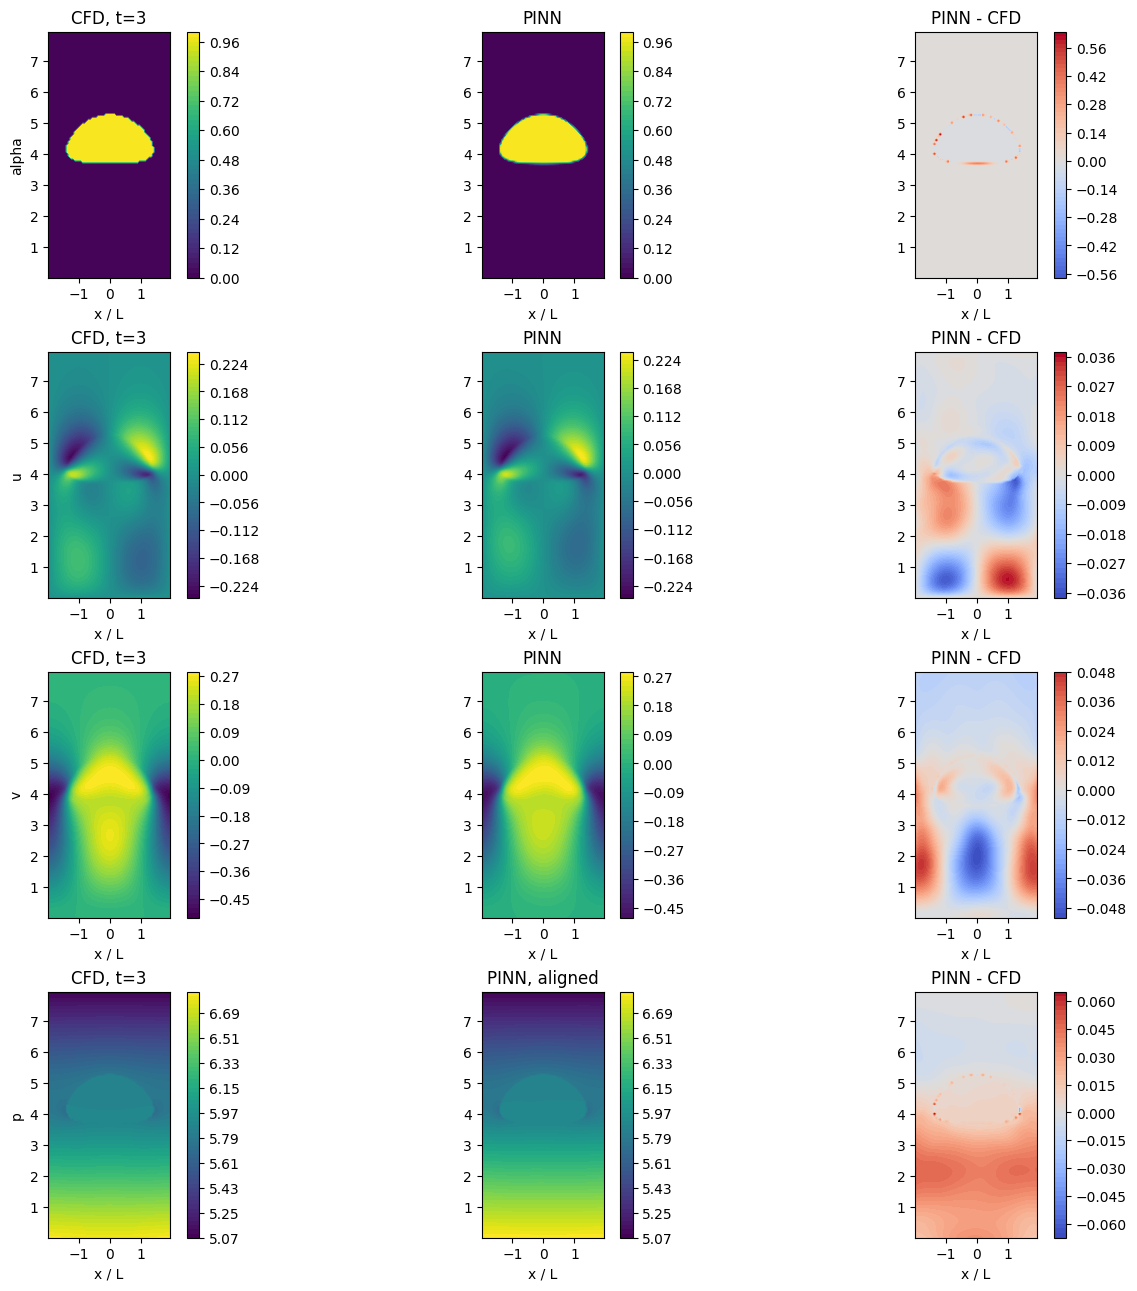

In [11]:
time_index = -1  # -1 = последний выбранный временной слой
fig = plot_field_comparison(
    pred,
    true,
    coords,
    time_index=time_index,
    fields=("alpha", "u", "v", "p"),
    save_path=run.run_dir / f"comparison_t{time_index}.png",
)

In [ ]:
# Вертикальный профиль через центр домена. Удобно смотреть alpha, u, v или p.
plot_centerline(pred, true, coords, field="alpha", time_index=time_index, x_value=0.0);